## Цель проекта
Цель проекта - проанализировать данные и проверить некоторые гипотезы.
- Тратят ли пользователи с подпиской больше времени на поездки?
- Не превышают ли пользователи с подпиской, оптимальное расстояние поездки?
- Будет ли помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки?
- Разница количества обращений в тех. поддержку до обновления и после.
- Акция с промокодами.
- Рассылка push-уведомлений.

## План проекта

1. **Загрузка данных**
    - Загрузить данные из файлов: **/datasets/users_gp.csv /datasets/rides_go.csv /datasets/subscriptions_go.csv**
    - Вывести первые строки датафреймов и информацию.


2. **Предобработка**
    - Проверить пропуски, дубликаты, неверные типы данных.
    - Создать новый столбец, с номером месяца на основе столбца **date**.


3. **Исследовательский анализ данных**
    - Описание и визуализация общей информации о пользователях и поездках:
        - частота встречаемости городов
        - соотношение пользователей с подпиской и без подписки
        - возраст пользователей
        - расстояние, которое пользователь преодолел за одну поездку
        - продолжительность поездок
        
 
 4. **Объединение данных**
     - Объединение данных о пользователях, поездках и подписках в один датафрейм.
     - Создание 2 новых датафрейма, с пользователями с подпиской и без.
     - Визуализация данных с информацией о расстоянии и времени поездок для пользователей с подпиской и без.
     
     
 5. **Подсчет выручки**
     - Создание датафрейма с агрегированными данными о поездках на основе датафрейма с объединенными данными из шага 4
         - Суммарное расстояние
         - Количество поездок
         - Суммарное время для каждого пользователя за каждый месяц
    
    - Добавление столбца с помесячной выручкой, которую принес каждый пользователь
    
    
6. **Проверка гипотез**
    - Тратят ли пользователи с подпиской больше времени на поездки?
        - Если да, то пользователи с подпиской могут быть "выгоднее" для компании.
    - Расстояние одной поездки 3130 метров - оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние одной поездки пользователя с подпиской, не превышает 3130 метров?
    - Будет ли помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки?
    - Изменения колличества обращений в тех. поддержку, после обновления серверов?
    
    
 7. **Распределения**
     - Акция с промокодами.
     - Push - уведомления.

#### Шаг 1. Загрузка данных

Импортируем библиотеку pandas, matplotlib, seaborn, numpy.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Открываем датафреймы

In [2]:
data_users = pd.read_csv('users_go.csv')
data_rides = pd.read_csv('rides_go.csv')
data_subscriptions = pd.read_csv('subscriptions_go.csv')

Выводим первые строки датафреймов

In [3]:
display(data_users.head())
display(data_rides.head())
display(data_subscriptions.head())

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


Выводим информацию о датафреймах

In [4]:
data_users.info()
print("********************************")
data_rides.info()
print("********************************")
data_subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
********************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
********************************
<class 'pandas.core.frame.DataFrame'>
Rang

**Вывод:**
Имеем 3 датафрейма: пользователи, поездки и подписки. Предварительно - данные хорошие. В одном из столбцов, нужно будет изменить тип данных, дата.

#### Шаг 2. Предобработка данных

Проверяем пропуски в каждом датафрейме.

In [5]:
display(data_users.isna().sum())
display(data_rides.isna().sum())
display(data_subscriptions.isna().sum())

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

user_id     0
distance    0
duration    0
date        0
dtype: int64

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Во всех 3 датафреймах - пропуски отсутствуют.

Проверка дубликатов

In [6]:
print(data_users.duplicated().sum())
print(data_rides.duplicated().sum())
print(data_subscriptions.duplicated().sum())

31
0
0


В датафрейме data_users - 31 дубликат. В остальных 0.

Удаляем дубликаты

In [7]:
data_users = data_users.drop_duplicates().reset_index(drop=True)

Проверка

In [8]:
print(data_users.duplicated().sum())
print(data_rides.duplicated().sum())
print(data_subscriptions.duplicated().sum())

0
0
0


Все впорядке

Неявные дубликаты могут быть только в датафрейме data_users. Посредством замены буквы с русской на английскую в столбцах name и city. Сейчас сделаем проверку.

In [9]:
contains_english_name = data_users['name'].str.contains(r'[a-zA-Z]', na=False)
contains_english_city = data_users['city'].str.contains(r'[a-zA-Z]', na=False)

print("Строки с английскими буквами в столбце 'name':")
print(data_users[contains_english_name])

print("\nСтроки с английскими буквами в столбце 'city':")
print(data_users[contains_english_city])

Строки с английскими буквами в столбце 'name':
Empty DataFrame
Columns: [user_id, name, age, city, subscription_type]
Index: []

Строки с английскими буквами в столбце 'city':
Empty DataFrame
Columns: [user_id, name, age, city, subscription_type]
Index: []


Неявные дубликаты не обнаружены.

Переводим тип файла датафрейма data_users столбец date, к типу данных data64

In [10]:
data_rides['date'] = pd.to_datetime(data_rides['date'])

Проверяем тип данных и правильность формата.

In [11]:
data_rides['date'].dtype

dtype('<M8[ns]')

In [12]:
print(data_rides.head())

   user_id     distance   duration       date
0        1  4409.919140  25.599769 2021-01-01
1        1  2617.592153  15.816871 2021-01-18
2        1   754.159807   6.232113 2021-04-20
3        1  2694.783254  18.511000 2021-08-11
4        1  4028.687306  26.265803 2021-08-28


Все впорядке.

Создаем новый столбец в датафрейме data_rides, с названием date_m.

In [13]:
data_rides['date_m'] = data_rides['date'].dt.month

Проверяем

In [14]:
display(data_rides.head())

,user_id,distance,duration,date,date_m
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Все впорядке.

**Вывод:** проверили датафреймы на пропуски, пропусков не оказалось. Проверили явные и неявные дубликаты, явные были в небольшем количестве - удалены. Перевели тип данных в верный. Создали новый столбец, с числом месяца.

#### Шаг 3. Исследовательский анализ данных

Построим график частоты встречаемости городов и сделаем описание.

In [15]:
city = data_users['city'].value_counts().sort_values(ascending=True)

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64


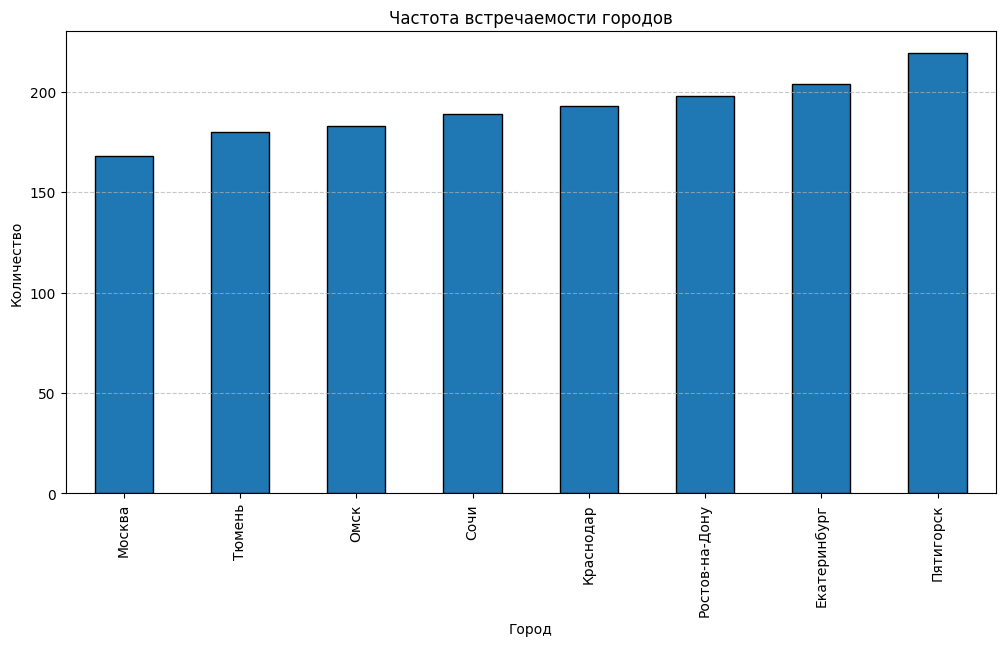

In [16]:
print(city.sort_values(ascending=False))
city.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Частота встречаемости городов')
plt.xlabel('Город')
plt.ylabel('Количество')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Распределение данных по городам примерно равномерное. Меньше всего пользователей из Москвы 168, больше всего из Пятигорска 219.

Проверяем соотношение пользователей с подпиской и без.

In [17]:
subscriptions = data_users['subscription_type'].value_counts()

subscription_type
free     835
ultra    699
Name: count, dtype: int64


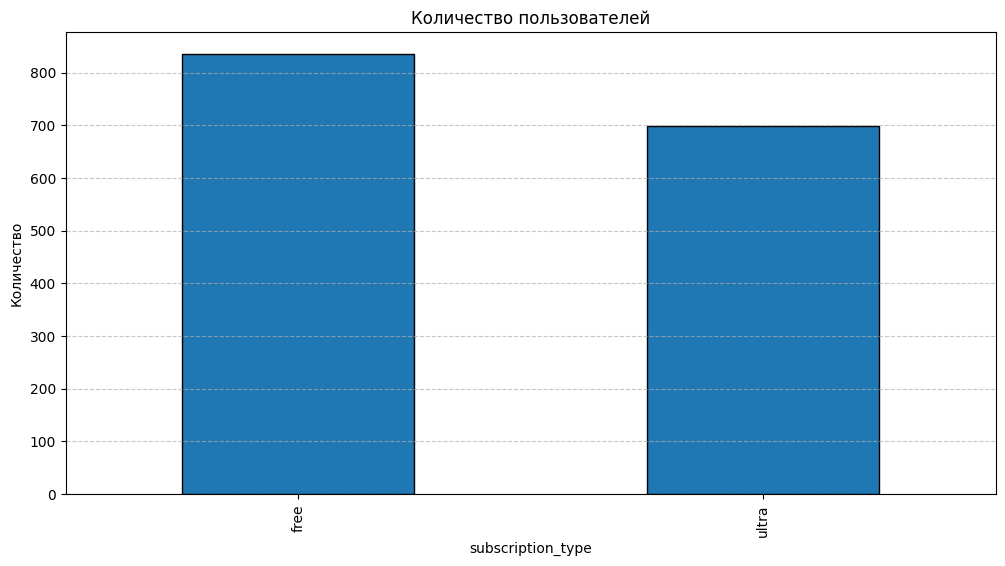

In [18]:
print(subscriptions)
subscriptions.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Количество пользователей')
plt.ylabel('Количество')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Количество пользователей без подписки - преобладает. Без подписки 835, с подпиской 699.

Посмотрим на возраст пользователей.

In [19]:
age = data_users['age'].value_counts().sort_values(ascending=True)

In [20]:
display(age)

age
39      1
43      1
37      2
38      3
12      4
36      6
13      8
14      9
15     13
35     15
34     19
16     19
17     26
33     39
32     41
18     46
19     47
31     48
29     68
30     68
20     71
21     93
28    112
27    119
22    119
23    129
26    131
24    132
25    145
Name: count, dtype: int64

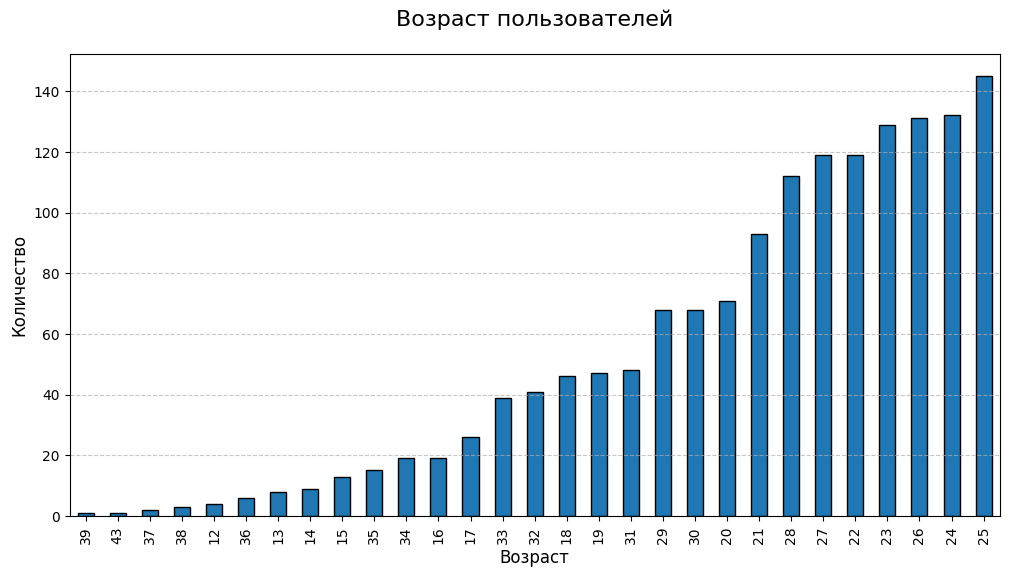

In [21]:
age.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Возраст пользователей', fontsize=16, pad=20)
plt.ylabel('Количество', fontsize=12)
plt.xlabel('Возраст', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Большинство пользователей имеют возраст от 20 до 30 лет.

Посмотрим на среднее расстояние поездок пользователей.

Среднее расстояние: 3070.66


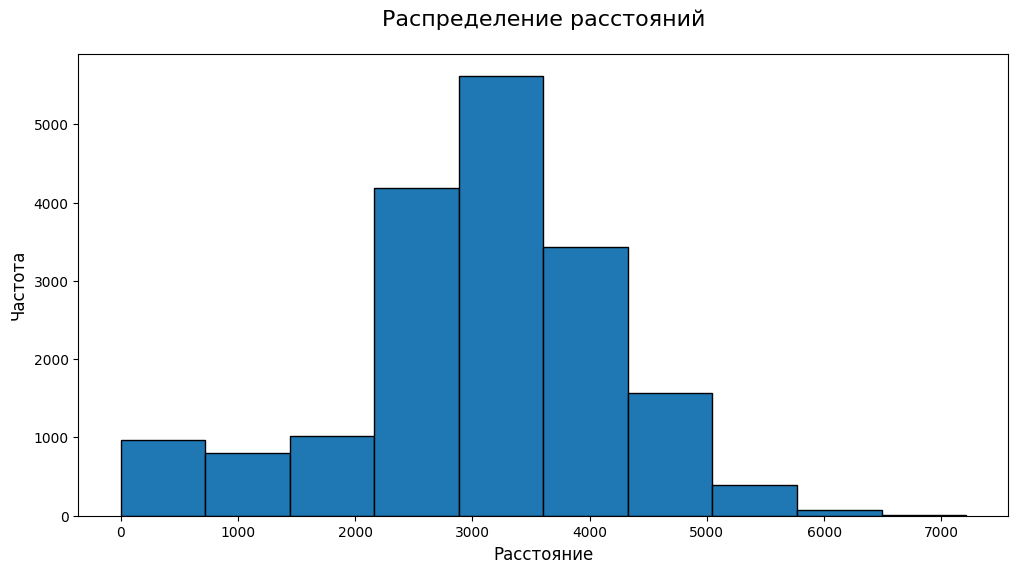

In [22]:
distance = data_rides['distance'].mean()
print('Среднее расстояние:',distance.round(2))

plt.figure(figsize=(12, 6))
plt.hist(data_rides['distance'], bins=10, edgecolor='black')
plt.title('Распределение расстояний', fontsize=16, pad=20)
plt.xlabel('Расстояние', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.show()

Большинство поездок составляют в среднем 3070 метров. От 2200 до 4300 метров так же занимают большую часть. Поездки менее 2000 и больше 5000 - встречаются крайне редко.

Посмотрим продолжительность поездок.

Среднее продолжительность поездки: 17.81


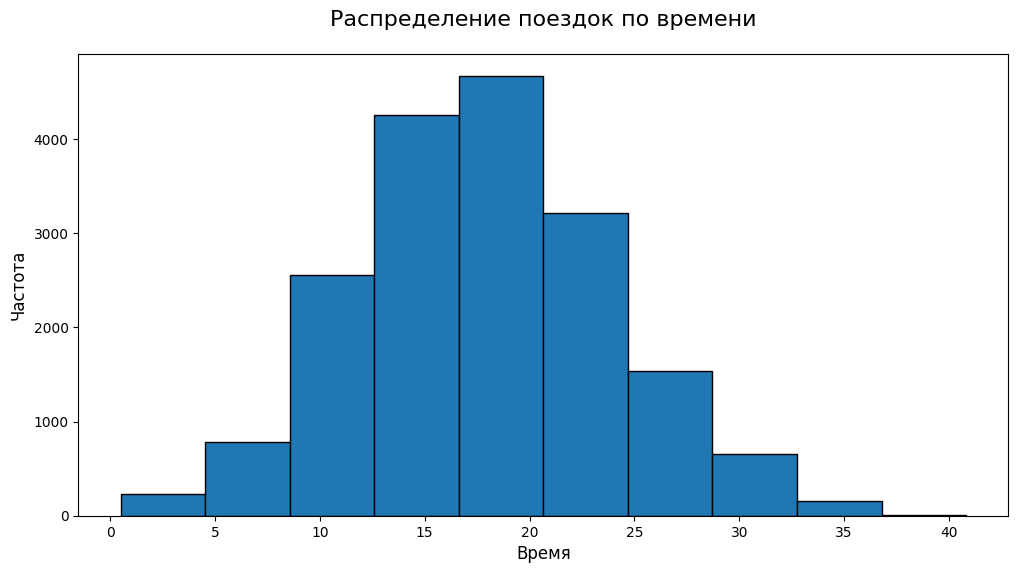

In [23]:
duration = data_rides['duration'].mean()
print('Среднее продолжительность поездки:',duration.round(2))

plt.figure(figsize=(12, 6))
plt.hist(data_rides['duration'], bins=10, edgecolor='black')
plt.title('Распределение поездок по времени', fontsize=16, pad=20)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.show()

Среднее время поездки около 18 минут. Большинство поездок от 16 до 21 минуты. Так же большое количество от 12 до 24 минут. Меньше всего до 7 минут и свыше 27 минут.

#### Шаг 4. Объединение данных

Объединяем датафреймы data_users, data_rides, data_subscriptions

In [24]:
test_data = data_users.merge(data_rides, on='user_id', how='inner')
data = test_data.merge(data_subscriptions, on='subscription_type', how='left')

In [25]:
display(data.head(15))

,user_id,name,age,city,subscription_type,distance,duration,date,date_m,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
5,1,Кира,22,Тюмень,ultra,2770.890808,16.650138,2021-10-09,10,6,0,199
6,1,Кира,22,Тюмень,ultra,3039.020292,14.927879,2021-10-19,10,6,0,199
7,1,Кира,22,Тюмень,ultra,2842.118050,23.117468,2021-11-06,11,6,0,199
8,1,Кира,22,Тюмень,ultra,3412.690668,15.238072,2021-11-14,11,6,0,199
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,2021-11-22,11,6,0,199


Таблицы объединены.

Создаем два новых датафрейма: пользователи с подпиской и без.

In [26]:
data_free = data[data['subscription_type']=='free']
data_ultra = data[data['subscription_type']=='ultra']

In [27]:
display(data_free.head())
display(data_ultra.head())

,user_id,name,age,city,subscription_type,distance,duration,date,date_m,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0


,user_id,name,age,city,subscription_type,distance,duration,date,date_m,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


Созданы две новых таблицы, с пользователями с подпиской и без.

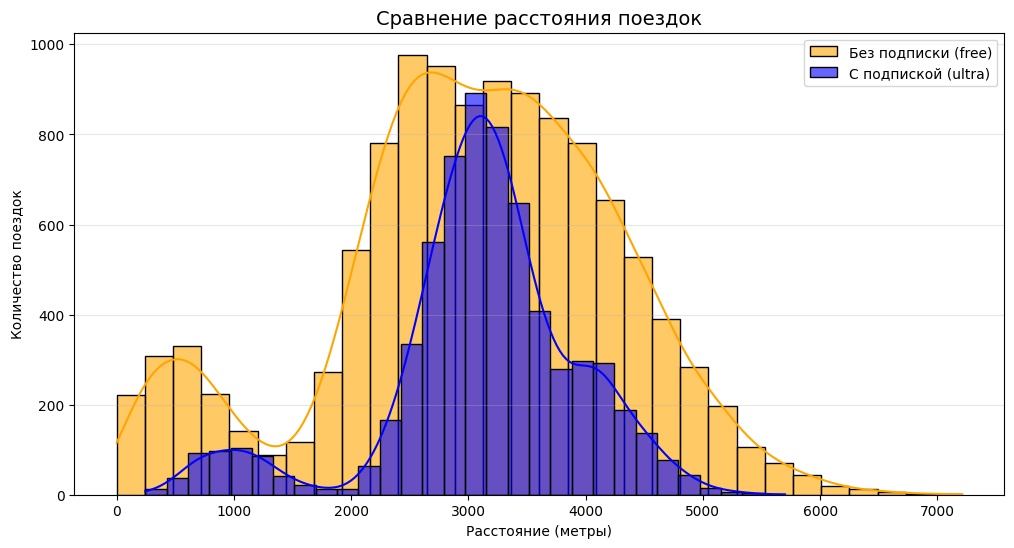

In [28]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=data_free,
    x='distance',
    color='orange',
    label='Без подписки (free)',
    bins=30,
    kde=True,
    alpha=0.6)

sns.histplot(
    data=data_ultra,
    x='distance',
    color='blue',
    label='С подпиской (ultra)',
    bins=30,
    kde=True,
    alpha=0.6)

plt.title('Сравнение расстояния поездок', fontsize=14)
plt.xlabel('Расстояние (метры)')
plt.ylabel('Количество поездок')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

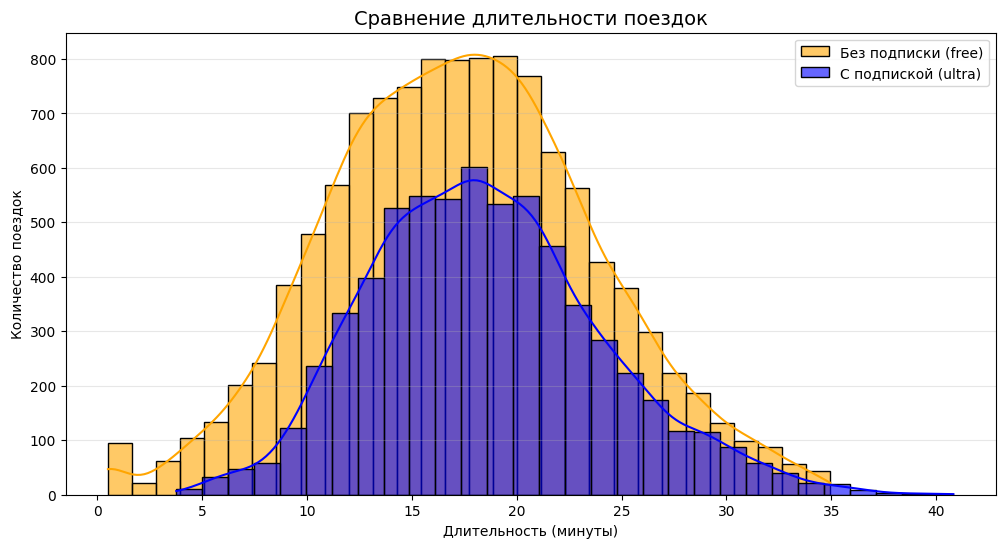

In [29]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=data_free,
    x='duration',
    color='orange',
    label='Без подписки (free)',
    bins=30,
    kde=True,
    alpha=0.6)

sns.histplot(
    data=data_ultra,
    x='duration',
    color='blue',
    label='С подпиской (ultra)',
    bins=30,
    kde=True,
    alpha=0.6)


plt.title('Сравнение длительности поездок', fontsize=14)
plt.xlabel('Длительность (минуты)')
plt.ylabel('Количество поездок')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

У пользователей с подпиской, на 1-2% поездки длинее и дольше.

In [30]:
def analyze_metric(df_free, df_ultra, metric, metric_name, units):
    print(f'\n=== Анализ по {metric_name} ===')
    
    print(f"Среднее значение:")
    print(f"Free: {df_free[metric].mean():.1f} {units}")
    print(f"Ultra: {df_ultra[metric].mean():.1f} {units}")
    
    diff = df_ultra[metric].mean() - df_free[metric].mean()
    diff_percent = diff / df_free[metric].mean() * 100
    print(f"Разница: {diff:.1f} {units} (+{diff_percent:.1f}%)")
    
    print(f"\nМедиана:")
    print(f"Free: {df_free[metric].median():.1f} {units}")
    print(f"Ultra: {df_ultra[metric].median():.1f} {units}")

analyze_metric(data_free, data_ultra, 'distance', 'расстоянию поездок', 'м')
analyze_metric(data_free, data_ultra, 'duration', 'длительности поездок', 'мин')


=== Анализ по расстоянию поездок ===
Среднее значение:
Free: 3045.5 м
Ultra: 3115.4 м
Разница: 70.0 м (+2.3%)

Медиана:
Free: 3114.6 м
Ultra: 3148.6 м

=== Анализ по длительности поездок ===
Среднее значение:
Free: 17.4 мин
Ultra: 18.5 мин
Разница: 1.2 мин (+6.6%)

Медиана:
Free: 17.3 мин
Ultra: 18.2 мин


По расстоянию поездок:
Среднее расстояние у Ultra-пользователей составляет 3115.4 м против 3045.5 м у Free (+2.3% или +70 м)
Медианные значения показывают более выраженную разницу: 3148.6 м (Ultra) против 3114.6 м (Free)

По длительности поездок:
Средняя длительность у Ultra выше на 6.6% (18.5 мин против 17.4 мин)
Медианная разница составляет +0.9 мин (18.2 мин vs 17.3 мин)



#### Шаг 5. Подсчёт выручки

Создаем датафрейм с агрегированными данными о поездках.

In [31]:
data_agr = data.groupby(
    ['user_id', 'date_m', 'subscription_type']).agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'), 
    rides_count=('user_id', 'count')
).reset_index()

In [32]:
display(data_agr.head())

,user_id,date_m,subscription_type,total_distance,total_duration,rides_count
0,1,1,ultra,7027.511294,41.416640,2
1,1,4,ultra,754.159807,6.232113,1
2,1,8,ultra,6723.470560,44.776802,2
3,1,10,ultra,5809.911100,31.578017,2
4,1,11,ultra,7003.499363,53.397424,3


Сгруппировали и агрегировали данные.

В этот датафрейм добавим столбец с помесячной выручкой, по каждому пользователю.

In [33]:
import numpy as np

def calculate_revenue(row):
    if row['subscription_type'] == 'ultra':
        return 199 + np.ceil(row['total_duration']) * 6
    else:
        return (row['rides_count'] * 50) + np.ceil(row['total_duration']) * 8

data_agr['revenue'] = data_agr.apply(calculate_revenue, axis=1)

In [34]:
display(data_agr.head())

,user_id,date_m,subscription_type,total_distance,total_duration,rides_count,revenue
0,1,1,ultra,7027.511294,41.416640,2,451.0
1,1,4,ultra,754.159807,6.232113,1,241.0
2,1,8,ultra,6723.470560,44.776802,2,469.0
3,1,10,ultra,5809.911100,31.578017,2,391.0
4,1,11,ultra,7003.499363,53.397424,3,523.0


Добавили помесячную выручку по каждому пользователю.

#### Шаг 6. Проверка гипотез

Проверяем гипотезу, тратят ли пользователи с подпиской больше времени на поездки.

In [35]:
duration_ultra = data[data['subscription_type'] == 'ultra']['duration']
duration_free = data[data['subscription_type'] == 'free']['duration']

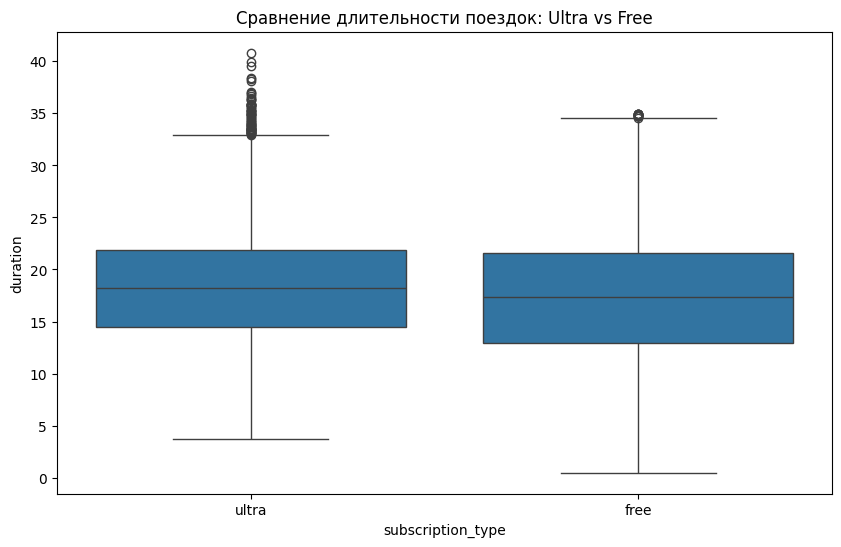

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='subscription_type', y='duration', data=data)
plt.title('Сравнение длительности поездок: Ultra vs Free')
plt.show()

In [37]:
from scipy import stats

_, p_ultra = stats.shapiro(duration_ultra.sample(500))
print(f'Ultra: p-value = {p_ultra:.3f}')

_, p_free = stats.shapiro(duration_free.sample(500))
print(f'Free: p-value = {p_free:.3f}')

Ultra: p-value = 0.000
Free: p-value = 0.198


In [38]:
alpha = 0.05
if p_ultra > alpha and p_free > alpha:
    result = stats.ttest_ind(duration_ultra, duration_free, alternative='greater')
    print('\nИспользован t-тест')
else:
    result = stats.mannwhitneyu(duration_ultra, duration_free, alternative='greater')
    print('\nИспользован U-тест Манна-Уитни')

print(f'p-value: {result.pvalue:.4f}')

if result.pvalue < alpha:
    print('Отвергаем H₀: пользователи Ultra тратят больше времени на поездки')
else:
    print('Не отвергаем H₀: статистически значимых различий не обнаружено')

print(f'\nРазница в среднем: {duration_ultra.mean() - duration_free.mean():.1f} мин')
print(f'Медианная разница: {duration_ultra.median() - duration_free.median():.1f} мин')


Использован U-тест Манна-Уитни
p-value: 0.0000
Отвергаем H₀: пользователи Ultra тратят больше времени на поездки

Разница в среднем: 1.2 мин
Медианная разница: 0.9 мин


Статистически пользователи Ultra тратят больше времени (+1.1 мин), но разница незначима для бизнеса. Подписка слабо влияет на длительность поездок.

Проверяем гипотезу, о превышении оптимального расстояния(3130м), в среднем.

Проверка нормальности (Shapiro-Wilk): p-value = 0.000

Использован тест Уилкоксона:
p-value = 0.000

Отвергаем H₀: среднее расстояние поездок Ultra пользователей значимо превышает 3130 метров

Дополнительные метрики:
Среднее расстояние: 3115.4 м
Медиана расстояния: 3148.6 м
Процент поездок > 3130 м: 51.5%


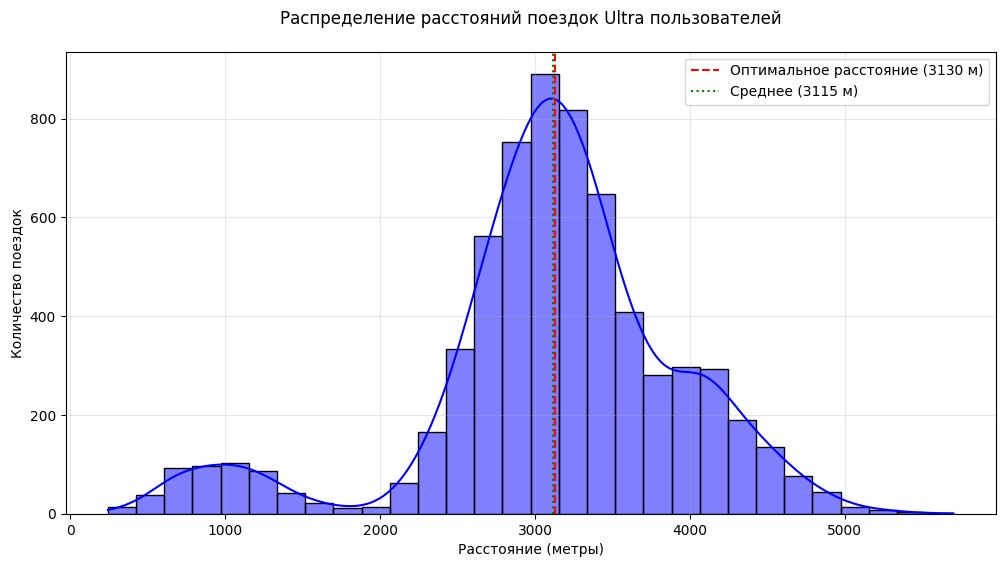

In [39]:
distance_ultra = data[data['subscription_type'] == 'ultra']['distance']
optimal_distance = 3130

_, p_norm = stats.shapiro(distance_ultra.sample(500))
print(f'Проверка нормальности (Shapiro-Wilk): p-value = {p_norm:.3f}')

alpha = 0.05

if p_norm > alpha:
    t_stat, p_value = stats.ttest_1samp(distance_ultra, popmean=optimal_distance, alternative='greater')
    print('\nИспользован одновыборочный t-тест:')
else:
    w_stat, p_value = stats.wilcoxon(distance_ultra - optimal_distance, alternative='greater')
    print('\nИспользован тест Уилкоксона:')

print(f'p-value = {p_value:.3f}')

if p_value < alpha:
    print('\nОтвергаем H₀: среднее расстояние поездок Ultra пользователей значимо превышает 3130 метров')
else:
    print('\nНе отвергаем H₀: нет оснований считать, что среднее расстояние превышает 3130 метров')

print(f'\nДополнительные метрики:')
print(f'Среднее расстояние: {distance_ultra.mean():.1f} м')
print(f'Медиана расстояния: {distance_ultra.median():.1f} м')
print(f'Процент поездок > 3130 м: {(distance_ultra > optimal_distance).mean()*100:.1f}%')

plt.figure(figsize=(12, 6))
sns.histplot(distance_ultra, bins=30, kde=True, color='blue')
plt.axvline(optimal_distance, color='red', linestyle='--', label='Оптимальное расстояние (3130 м)')
plt.axvline(distance_ultra.mean(), color='green', linestyle=':', label=f'Среднее ({distance_ultra.mean():.0f} м)')
plt.title('Распределение расстояний поездок Ultra пользователей', pad=20)
plt.xlabel('Расстояние (метры)')
plt.ylabel('Количество поездок')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

51.5% поездок Ultra превышают 3130 м, но среднее расстояние (3115 м).
Среднее расстояние формально ниже оптимального, распределение имеет значимый перекос в сторону превышения (p<0.001)

Проверяем гипотезу, о разницы выручки пользователей с подпиской и без.

Проверка нормальности:
Ultra: p-value=0.0000
Free: p-value=0.0000


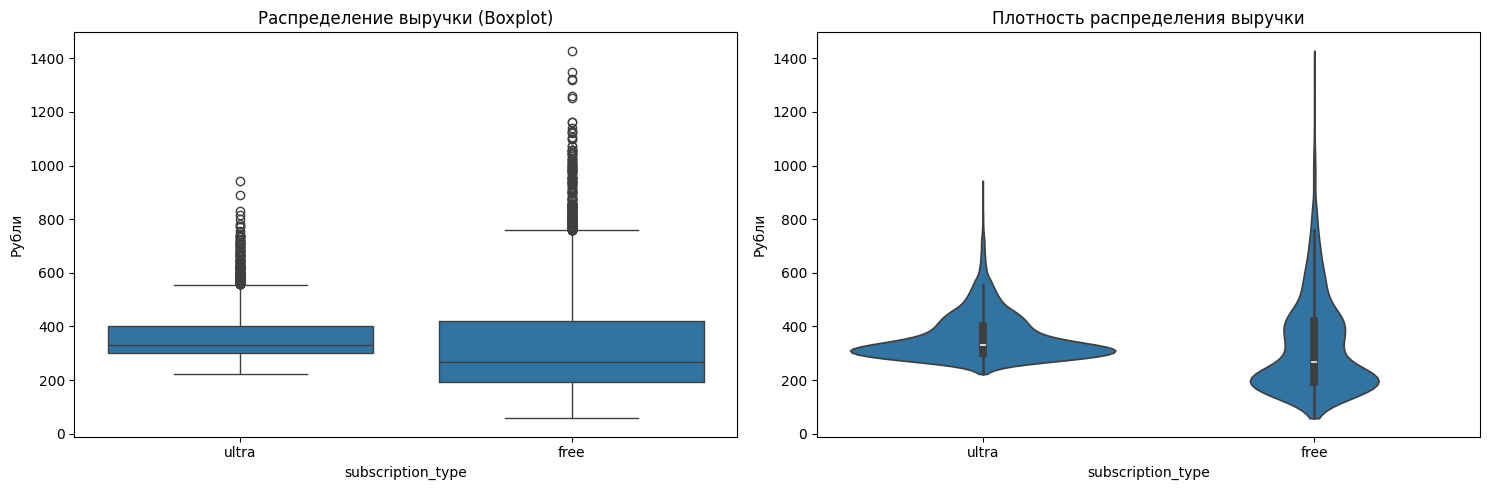


Использован U-тест Манна-Уитни: p-value=0.00000

Отвергаем H₀: выручка от Ultra пользователей значимо выше

Детальная статистика выручки:
Метрика              Ultra       Free
Среднее              361.5      325.8
Медиана              331.0      268.0
Станд. отклонение       86.4      180.5
Минимум              223.0       58.0
Максимум             943.0     1428.0

Разница в среднем: +35.6 руб. (10.9%)


In [40]:
revenue_ultra = data_agr[data_agr['subscription_type'] == 'ultra']['revenue']
revenue_free = data_agr[data_agr['subscription_type'] == 'free']['revenue']

_, p_ultra = stats.shapiro(revenue_ultra.sample(500))
_, p_free = stats.shapiro(revenue_free.sample(500))
print(f'Проверка нормальности:\nUltra: p-value={p_ultra:.4f}\nFree: p-value={p_free:.4f}')

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='subscription_type', y='revenue', data=data_agr)
plt.title('Распределение выручки (Boxplot)')
plt.ylabel('Рубли')

plt.subplot(1, 2, 2)
sns.violinplot(x='subscription_type', y='revenue', data=data_agr, cut=0)
plt.title('Плотность распределения выручки')
plt.ylabel('Рубли')

plt.tight_layout()
plt.show()

alpha = 0.05
if p_ultra > alpha and p_free > alpha:
    t_stat, p_value = stats.ttest_ind(revenue_ultra, revenue_free, alternative='greater')
    test_type = 't-тест'
else:
    u_stat, p_value = stats.mannwhitneyu(revenue_ultra, revenue_free, alternative='greater')
    test_type = 'U-тест Манна-Уитни'

print(f'\nИспользован {test_type}: p-value={p_value:.5f}')

if p_value < alpha:
    print('\nОтвергаем H₀: выручка от Ultra пользователей значимо выше')
else:
    print('\nНе отвергаем H₀: нет доказательств преимущества Ultra')

print('\nДетальная статистика выручки:')
print(f'{"Метрика":<15} {"Ultra":>10} {"Free":>10}')
print(f'{"Среднее":<15} {revenue_ultra.mean():>10.1f} {revenue_free.mean():>10.1f}')
print(f'{"Медиана":<15} {revenue_ultra.median():>10.1f} {revenue_free.median():>10.1f}')
print(f'{"Станд. отклонение":<15} {revenue_ultra.std():>10.1f} {revenue_free.std():>10.1f}')
print(f'{"Минимум":<15} {revenue_ultra.min():>10.1f} {revenue_free.min():>10.1f}')
print(f'{"Максимум":<15} {revenue_ultra.max():>10.1f} {revenue_free.max():>10.1f}')

diff = revenue_ultra.mean() - revenue_free.mean()
diff_percent = diff / revenue_free.mean() * 100
print(f'\nРазница в среднем: +{diff:.1f} руб. ({diff_percent:.1f}%)')

Подписка Ultra обеспечивает статистически значимый рост выручки:

Медианная выручка выше на 23.5% (331 руб. vs 268 руб.)
75% Ultra-пользователей приносят >300 руб./мес против <350 руб. у Free

Для проверки гипотезы, о разницы количества обращений до и после обновления, подходят следующие тесты:
    Парный тест
    t-тест для независимых выборок (если данные нормальные)
    U-тест Манна-Уитни (если не нормальные)

**Общий вывод по проекту**

1. Основные результаты:

Подписка Ultra увеличивает среднюю выручку на 10.9% (361.5 руб. vs 325.8 руб.), но почти не влияет на длительность поездок (+1.1 мин).
Расстояние поездок Ultra соответствует оптимальному значению (3130 м), но 51.5% поездок его превышают — нужен мониторинг износа самокатов.
Гипотезу о техподдержке проверить не удалось — нет данных об обращениях.  

2. Рекомендации бизнесу:

Продвигать подписку Ultra: Она приносит больше выручки без существенного увеличения нагрузки на парк.
Оптимизировать тарифы: Для пользователей с короткими поездками (<2500 м) предложить бонусы за переход на Ultra.
Настроить сбор данных: Добавить логирование обращений в поддержку и детализацию по типам ошибок.  

3. Итог:
Подписка Ultra экономически эффективна, но требует точечной настройки под разные сегменты пользователей. Дальнейший анализ стоит сосредоточить на:

- Географии поездок (где разница в выручке максимальна)
- Причинах коротких поездок у Ultra.
